# Где дешевле жить? Предсказание цен в Airbnb - учимся генерировать признаки и интерпретировать результаты модели

In [30]:
'''1 Часть EDA'''
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#загрузка данных

df = pd.read_csv("AB_NYC_2019.csv")

df.head()

#проверка 
df.shape
df.info()
df.describe()



<class 'pandas.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              48895 non-null  int64  
 1   name                            48879 non-null  str    
 2   host_id                         48895 non-null  int64  
 3   host_name                       48874 non-null  str    
 4   neighbourhood_group             48895 non-null  str    
 5   neighbourhood                   48895 non-null  str    
 6   latitude                        48895 non-null  float64
 7   longitude                       48895 non-null  float64
 8   room_type                       48895 non-null  str    
 9   price                           48895 non-null  int64  
 10  minimum_nights                  48895 non-null  int64  
 11  number_of_reviews               48895 non-null  int64  
 12  last_review                     38843 non-n

,id,host_id,latitude,longitude,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
count,4.889500e+04,4.889500e+04,48895.000000,48895.000000,48895.000000,48895.000000,48895.000000,38843.000000,48895.000000,48895.000000
mean,1.901714e+07,6.762001e+07,40.728949,-73.952170,152.720687,7.029962,23.274466,1.373221,7.143982,112.781327
std,1.098311e+07,7.861097e+07,0.054530,0.046157,240.154170,20.510550,44.550582,1.680442,32.952519,131.622289
min,2.539000e+03,2.438000e+03,40.499790,-74.244420,0.000000,1.000000,0.000000,0.010000,1.000000,0.000000
25%,9.471945e+06,7.822033e+06,40.690100,-73.983070,69.000000,1.000000,1.000000,0.190000,1.000000,0.000000
50%,1.967728e+07,3.079382e+07,40.723070,-73.955680,106.000000,3.000000,5.000000,0.720000,1.000000,45.000000
75%,2.915218e+07,1.074344e+08,40.763115,-73.936275,175.000000,5.000000,24.000000,2.020000,2.000000,227.000000
max,3.648724e+07,2.743213e+08,40.913060,-73.712990,10000.000000,1250.000000,629.000000,58.500000,327.000000,365.000000


In [31]:
#удаляем признаки
df = df.drop(
    columns=[
        "id",
        "name",
        "host_id",
        "host_name",
        "last_review"
    ]
)
df.head()
df.shape
#проверка на пропуски
df.isnull().sum()
df["reviews_per_month"] = df["reviews_per_month"].fillna(0)
df.isnull().sum()



neighbourhood_group               0
neighbourhood                     0
latitude                          0
longitude                         0
room_type                         0
price                             0
minimum_nights                    0
number_of_reviews                 0
reviews_per_month                 0
calculated_host_listings_count    0
availability_365                  0
dtype: int64

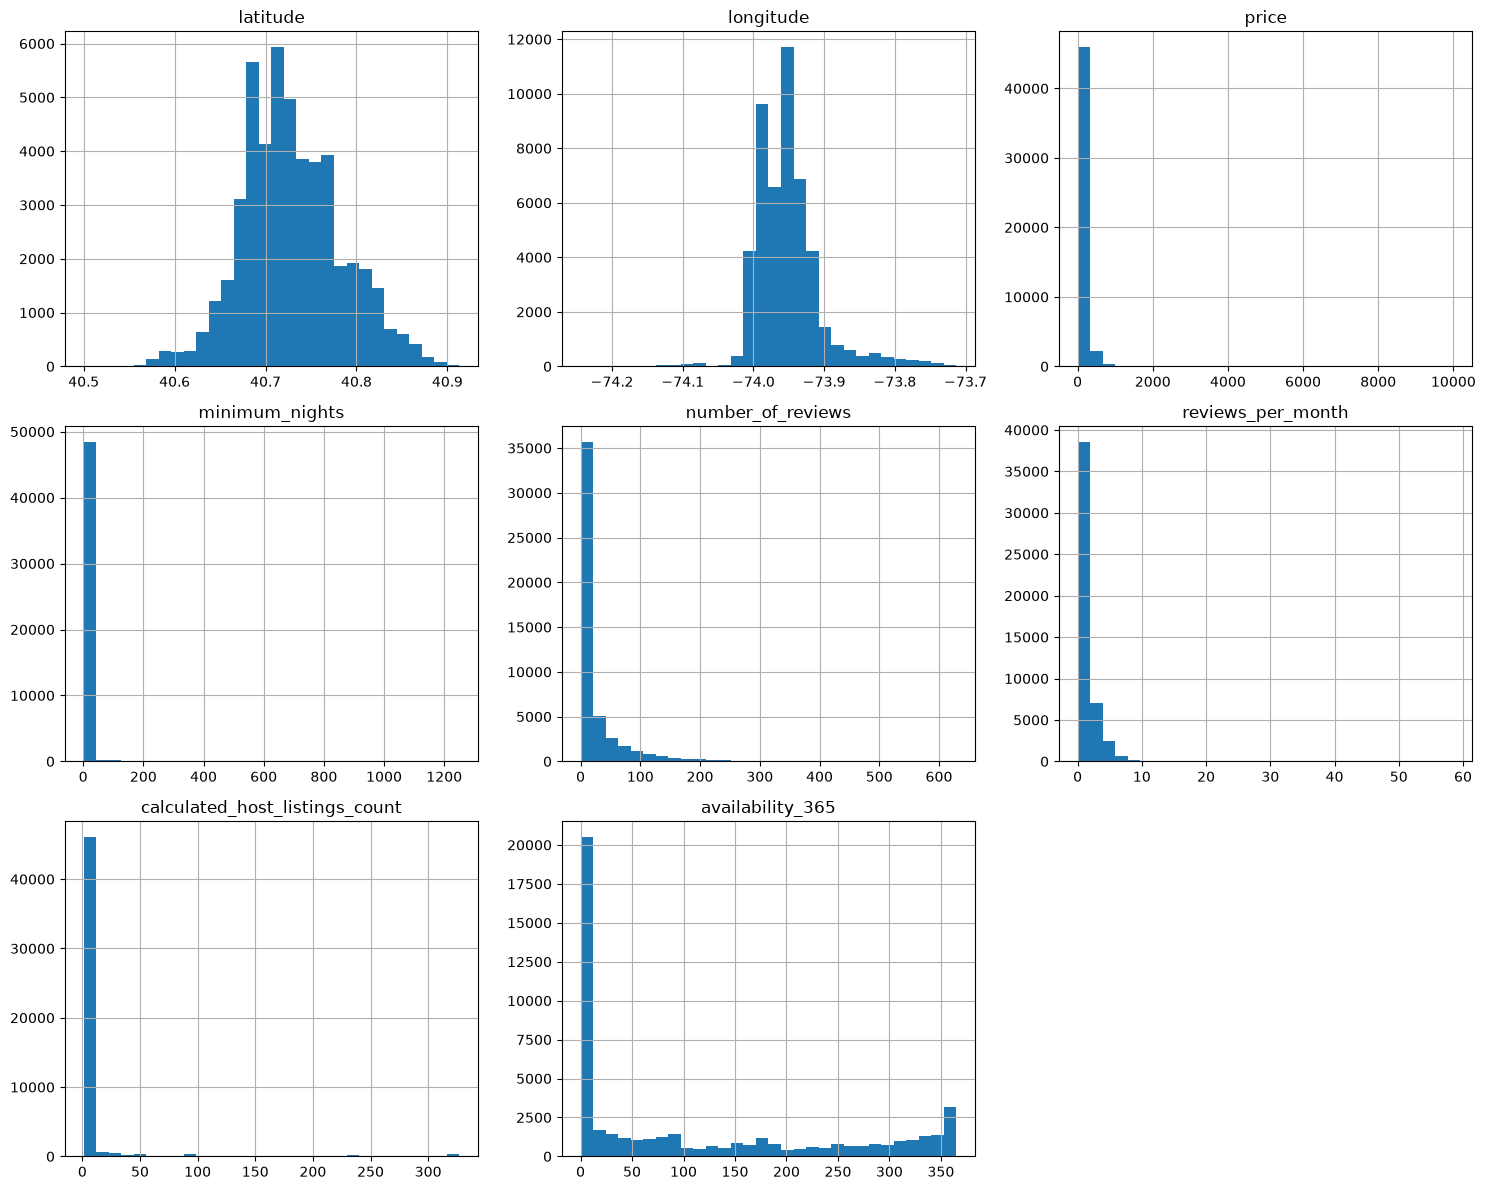

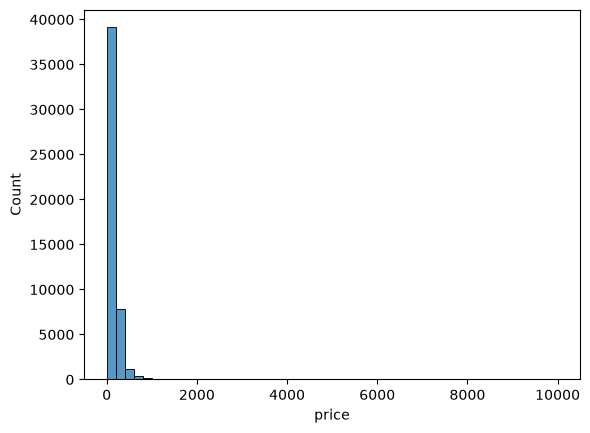

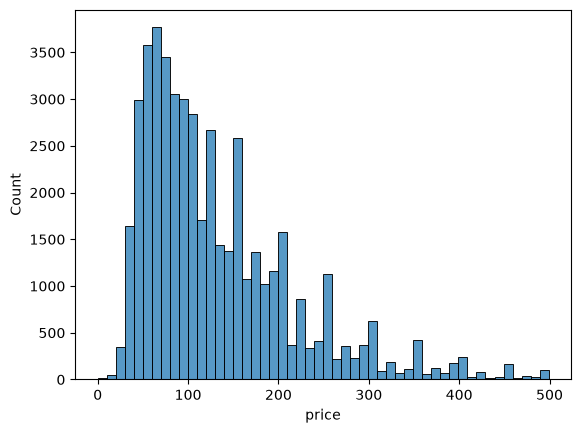

In [32]:
#базовые статистики
df.describe()

#распределение признаков
numeric_columns = df.select_dtypes(include="number").columns

numeric_columns

df[numeric_columns].hist(
    figsize=(15, 12),
    bins=30
)

plt.tight_layout()
plt.show()

# у параметра price есть выбросы
sns.histplot(
    data=df,
    x="price",
    bins=50
)

plt.show()

sns.histplot(
    data=df[df["price"] < 500],
    x="price",
    bins=50
)

plt.show()



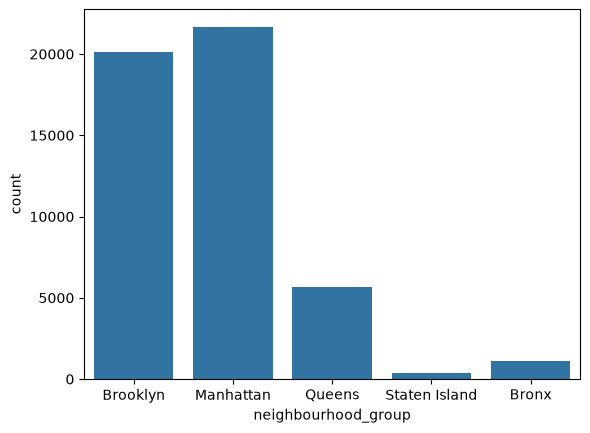

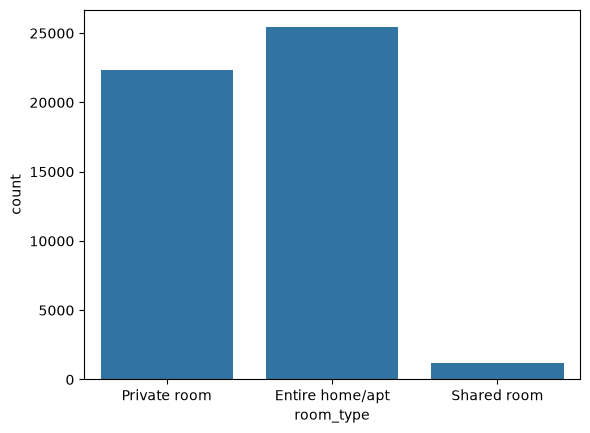

In [33]:
#категориальные признаки
sns.countplot(
    data=df,
    x="neighbourhood_group"
)

plt.show()

sns.countplot(
    data=df,
    x="room_type"
)

plt.show()

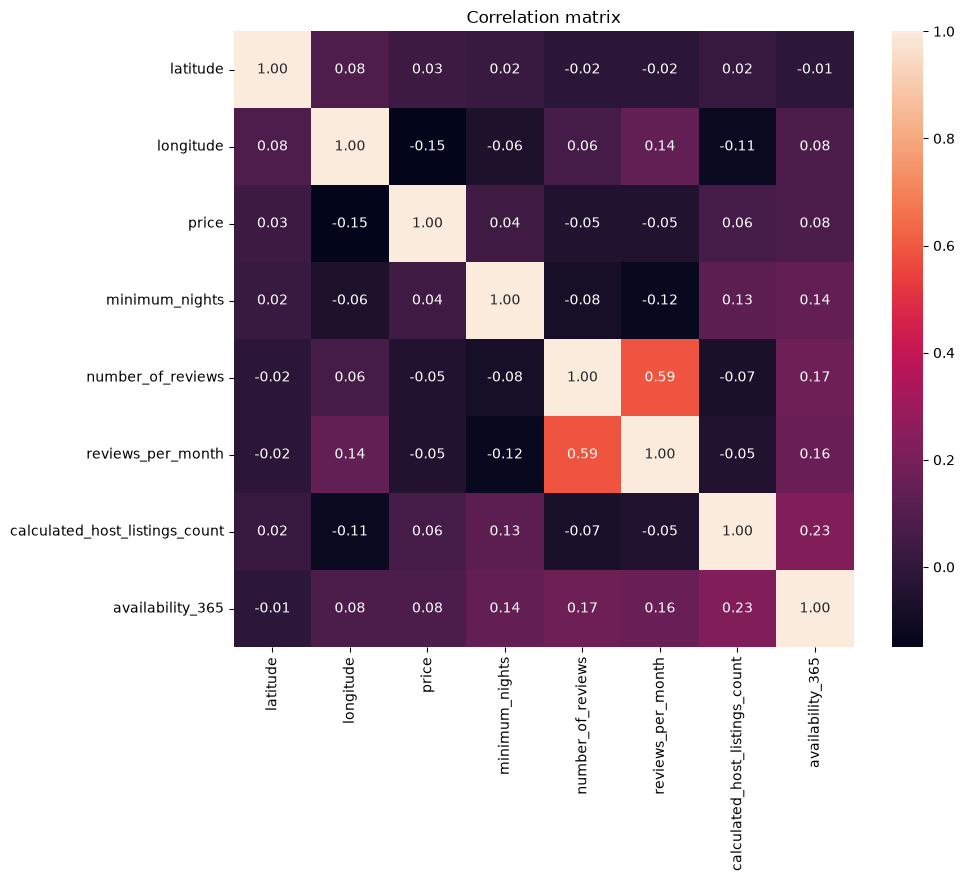

In [ ]:
#матрица попарныхкорреляций
corr = df.select_dtypes(include="number").corr()

plt.figure(figsize=(10, 8))

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f"
)

plt.title("Correlation matrix")
plt.show()

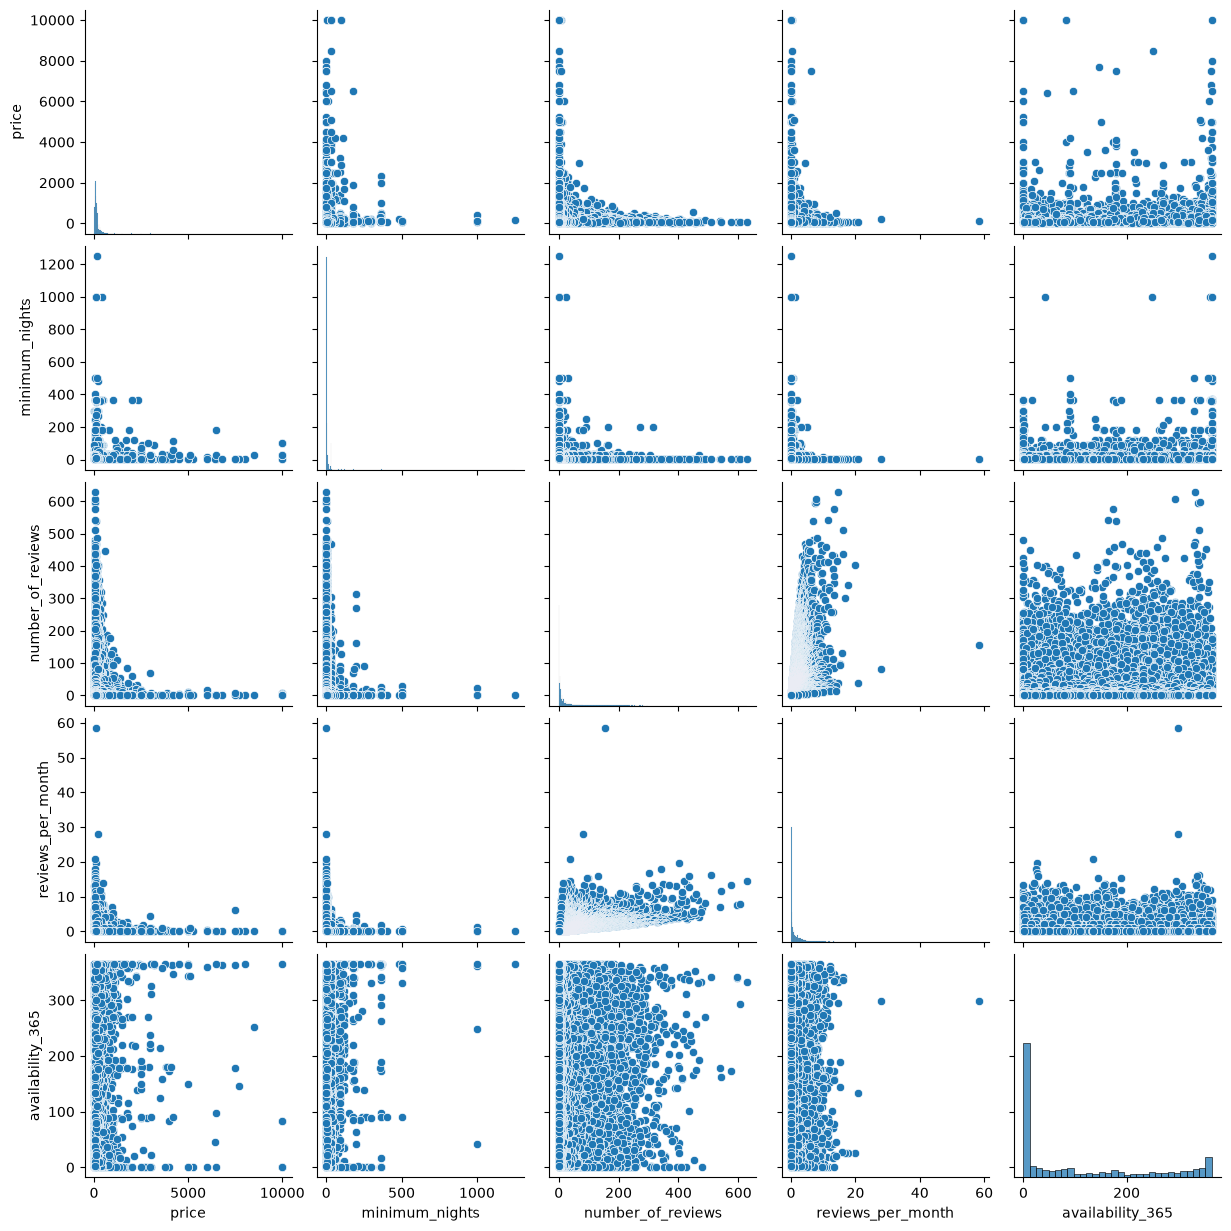

In [35]:
# Pairplot
pair_columns = [
    "price",
    "minimum_nights",
    "number_of_reviews",
    "reviews_per_month",
    "availability_365"
]

sns.pairplot(
    df[pair_columns]
)


plt.show()

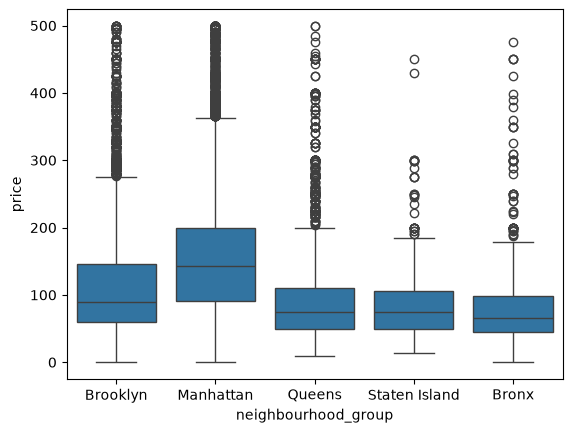

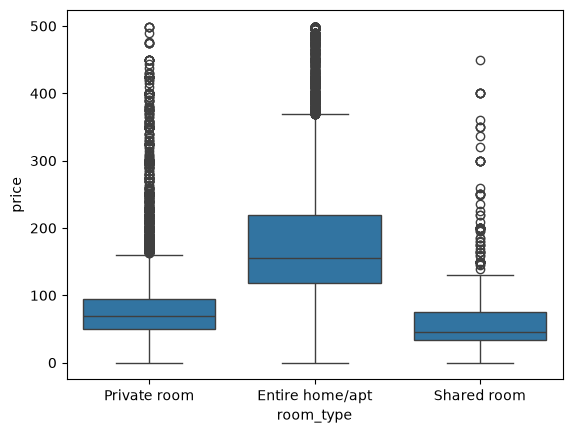

In [36]:
# зависимость цены от района
sns.boxplot(
    data=df[df["price"] < 500],
    x="neighbourhood_group",
    y="price"
)

plt.show()
#зависимость цены от типа жилья
sns.boxplot(
    data=df[df["price"] < 500],
    x="room_type",
    y="price"
)

plt.show()

In [37]:
#предобработка
df_processed = df.copy()

#объявления без отзывов
df_processed["reviews_per_month"] = (
    df_processed["reviews_per_month"].fillna(0)
)

df_processed.isnull().sum()
#удаляем цену меньше 0
(df_processed["price"] <= 0).sum()
df_processed = df_processed[
    df_processed["price"] > 0
].copy()



In [38]:
'''2 Часть  Preprocessing & Feature Engineering'''
#разделяем признаки и целевую переменную
X = df_processed.drop(columns=["price"])
y = df_processed["price"]

In [39]:
# Выполняем train/test split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(39107, 10)
(9777, 10)
(39107,)
(9777,)


In [40]:
#функция оценки
from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error
)

results = []

def evaluate_model(name, model, X_train, X_test, y_train, y_test):
    model.fit(X_train, y_train)

    prediction = model.predict(X_test)

    r2 = r2_score(y_test, prediction)
    mae = mean_absolute_error(y_test, prediction)
    rmse = np.sqrt(
        mean_squared_error(y_test, prediction)
    )

    results.append({
        "experiment": name,
        "R2": r2,
        "MAE": mae,
        "RMSE": rmse
    })

    print(name)
    print(f"R2   = {r2:.4f}")
    print(f"MAE  = {mae:.2f}")
    print(f"RMSE = {rmse:.2f}")

    return prediction

In [41]:
#Dummy  + LinearRegression
categorical_columns = X_train.select_dtypes(
    include=["object"]
).columns.tolist()

numeric_columns = X_train.select_dtypes(
    include=["number"]
).columns.tolist()

print("Категориальные:")
print(categorical_columns)

print()

print("Числовые:")
print(numeric_columns)

Категориальные:
['neighbourhood_group', 'neighbourhood', 'room_type']

Числовые:
['latitude', 'longitude', 'minimum_nights', 'number_of_reviews', 'reviews_per_month', 'calculated_host_listings_count', 'availability_365']


/var/folders/y9/6s0rr4pn7kg0jv3lq5c10rfm0000gn/T/ipykernel_74238/2381853677.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = X_train.select_dtypes(


In [42]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression

preprocessor_dummy = ColumnTransformer([
    (
        "categorical",
        OneHotEncoder(
            handle_unknown="ignore",
            drop="first"
        ),
        categorical_columns
    ),
    (
        "numeric",
        "passthrough",
        numeric_columns
    )
])

#модель 
model_dummy = Pipeline([
    ("preprocessing", preprocessor_dummy),
    ("model", LinearRegression())
])

#запуск. C этой моделью мы в дальнейшем и будем сравнивать результаты
pred_dummy = evaluate_model(
    "Dummy",
    model_dummy,
    X_train,
    X_test,
    y_train,
    y_test
)

Dummy
R2   = 0.1357
MAE  = 70.78
RMSE = 186.02


/Users/ios.timur.gaysinicloud.com/workspace/otus-lessons/.venv/lib/python3.14/site-packages/sklearn/preprocessing/_encoders.py:262: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


In [43]:
#StandardScaler 

from sklearn.preprocessing import StandardScaler

preprocessor_standard = ColumnTransformer([
    (
        "categorical",
        OneHotEncoder(
            handle_unknown="ignore",
            drop="first"
        ),
        categorical_columns
    ),
    (
        "numeric",
        StandardScaler(),
        numeric_columns
    )
])

model_standard = Pipeline([
    ("preprocessing", preprocessor_standard),
    ("model", LinearRegression())
])

pred_standard = evaluate_model(
    "Dummy + StandardScaler",
    model_standard,
    X_train,
    X_test,
    y_train,
    y_test
)

Dummy + StandardScaler
R2   = 0.1351
MAE  = 70.83
RMSE = 186.08


/Users/ios.timur.gaysinicloud.com/workspace/otus-lessons/.venv/lib/python3.14/site-packages/sklearn/preprocessing/_encoders.py:262: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


In [44]:
#RobustScaler
from sklearn.preprocessing import RobustScaler

preprocessor_robust = ColumnTransformer([
    (
        "categorical",
        OneHotEncoder(
            handle_unknown="ignore",
            drop="first"
        ),
        categorical_columns
    ),
    (
        "numeric",
        RobustScaler(),
        numeric_columns
    )
])

model_robust = Pipeline([
    ("preprocessing", preprocessor_robust),
    ("model", LinearRegression())
])

pred_robust = evaluate_model(
    "Dummy + RobustScaler",
    model_robust,
    X_train,
    X_test,
    y_train,
    y_test
)

Dummy + RobustScaler
R2   = 0.1350
MAE  = 70.85
RMSE = 186.10


/Users/ios.timur.gaysinicloud.com/workspace/otus-lessons/.venv/lib/python3.14/site-packages/sklearn/preprocessing/_encoders.py:262: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


In [45]:
#работа с аномалиями
X_train_clipped = X_train.copy()
X_test_clipped = X_test.copy()

columns_to_clip = [
    "minimum_nights",
    "number_of_reviews",
    "reviews_per_month",
    "calculated_host_listings_count"
]

for column in columns_to_clip:

    lower = X_train[column].quantile(0.01)
    upper = X_train[column].quantile(0.99)

    X_train_clipped[column] = (
        X_train[column].clip(lower, upper)
    )

    X_test_clipped[column] = (
        X_test[column].clip(lower, upper)
    )

pred_clipped = evaluate_model(
    "RobustScaler + clipping",
    model_robust,
    X_train_clipped,
    X_test_clipped,
    y_train,
    y_test
)

RobustScaler + clipping
R2   = 0.1376
MAE  = 70.85
RMSE = 185.81


/Users/ios.timur.gaysinicloud.com/workspace/otus-lessons/.venv/lib/python3.14/site-packages/sklearn/preprocessing/_encoders.py:262: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


In [46]:
#центр Манхэттена

manhattan = X_train_clipped[
    X_train_clipped["neighbourhood_group"] == "Manhattan"
]

manhattan_latitude = manhattan["latitude"].median()
manhattan_longitude = manhattan["longitude"].median()

print("Latitude:", manhattan_latitude)
print("Longitude:", manhattan_longitude)

#евклидово расстояние

def add_features(data):
    result = data.copy()

    result["distance_to_manhattan"] = np.sqrt(
        (result["latitude"] - manhattan_latitude) ** 2
        +
        (result["longitude"] - manhattan_longitude) ** 2
    )

    return result

X_train_fe = add_features(X_train_clipped)
X_test_fe = add_features(X_test_clipped)

X_train_fe[
    [
        "latitude",
        "longitude",
        "distance_to_manhattan"
    ]
].head()

Latitude: 40.76104
Longitude: -73.980325


,latitude,longitude,distance_to_manhattan
44559,40.70840,-73.78882,0.198608
31363,40.70343,-73.93412,0.073850
42274,40.89981,-73.86684,0.179265
11756,40.74526,-73.99545,0.021858
23350,40.67075,-73.97690,0.090355


In [49]:
#добавляем признаки для ассиметричных переменных

log_columns = [
    "minimum_nights",
    "number_of_reviews",
    "reviews_per_month",
    "calculated_host_listings_count"
]

for column in log_columns:

    X_train_fe[f"log_{column}"] = np.log1p(
        X_train_fe[column]
    )

    X_test_fe[f"log_{column}"] = np.log1p(
        X_test_fe[column]
    )

categorical_fe = X_train_fe.select_dtypes(
    include=["object"]
).columns.tolist()

numeric_fe = X_train_fe.select_dtypes(
    include=["number"]
).columns.tolist()

preprocessor_fe = ColumnTransformer([
    (
        "categorical",
        OneHotEncoder(
            handle_unknown="ignore",
            drop="first"
        ),
        categorical_fe
    ),
    (
        "numeric",
        RobustScaler(),
        numeric_fe
    )
])

model_fe = Pipeline([
    ("preprocessing", preprocessor_fe),
    ("model", LinearRegression())
])

pred_fe = evaluate_model(
    "Feature Engineering",
    model_fe,
    X_train_fe,
    X_test_fe,
    y_train,
    y_test
)

Feature Engineering
R2   = 0.1456
MAE  = 71.52
RMSE = 184.95


/var/folders/y9/6s0rr4pn7kg0jv3lq5c10rfm0000gn/T/ipykernel_74238/2490561380.py:20: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_fe = X_train_fe.select_dtypes(
/Users/ios.timur.gaysinicloud.com/workspace/otus-lessons/.venv/lib/python3.14/site-packages/sklearn/preprocessing/_encoders.py:262: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


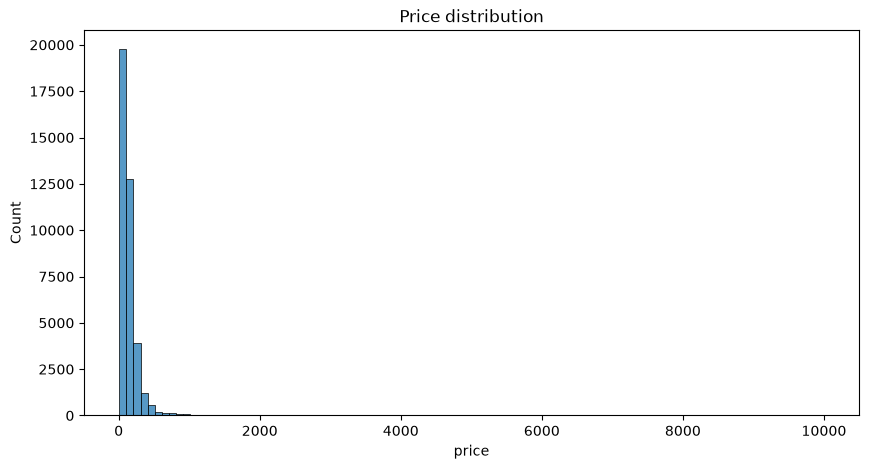

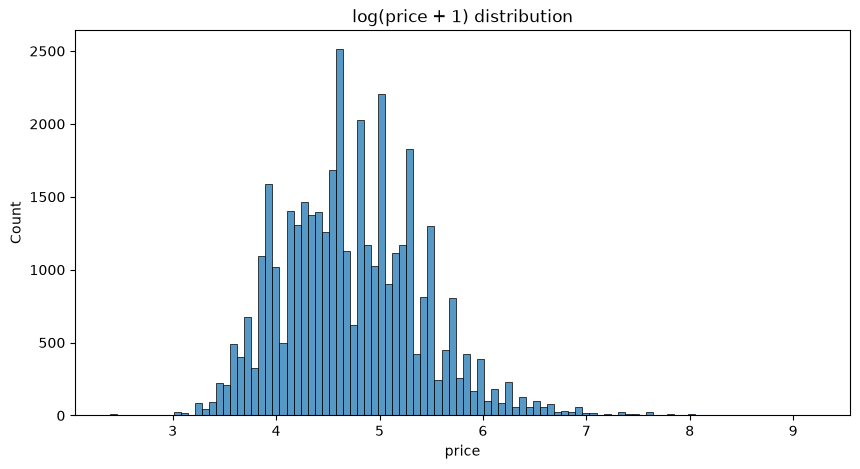

Feature Engineering + log(price)
R2   = 0.1365
MAE  = 59.20
RMSE = 185.93


/Users/ios.timur.gaysinicloud.com/workspace/otus-lessons/.venv/lib/python3.14/site-packages/sklearn/preprocessing/_encoders.py:262: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


In [50]:
#работа с целевой переменной price

plt.figure(figsize=(10, 5))

sns.histplot(
    y_train,
    bins=100
)

plt.title("Price distribution")
plt.show()

plt.figure(figsize=(10, 5))

sns.histplot(
    np.log1p(y_train),
    bins=100
)

plt.title("log(price + 1) distribution")
plt.show()

from sklearn.compose import TransformedTargetRegressor

model_log_target = TransformedTargetRegressor(
    regressor=model_fe,
    func=np.log1p,
    inverse_func=np.expm1
)

pred_log_target = evaluate_model(
    "Feature Engineering + log(price)",
    model_log_target,
    X_train_fe,
    X_test_fe,
    y_train,
    y_test
)

In [51]:
#сравнение экспериментов
results_df = pd.DataFrame(results)

results_df.sort_values(
    by="RMSE"
)

,experiment,R2,MAE,RMSE
4,Feature Engineering,0.145634,71.522562,184.946925
3,RobustScaler + clipping,0.137598,70.853672,185.814615
5,Feature Engineering + log(price),0.136522,59.199886,185.930493
0,Dummy,0.135707,70.780744,186.018284
1,Dummy + StandardScaler,0.135142,70.826668,186.079038
2,Dummy + RobustScaler,0.134965,70.850954,186.098054


In [54]:
'''Часть 3. Моделирование'''

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42
)

print("Train:", X_train.shape)
print("Test:", X_test.shape)


Train: (34218, 10)
Test: (14666, 10)


In [ ]:
#подготовка признаков

categorical_columns = X_train.select_dtypes(
    include=["object"]
).columns.tolist()

numeric_columns = X_train.select_dtypes(
    include=["number"]
).columns.tolist()

print("Categorical:", categorical_columns)
print("Numeric:", numeric_columns)

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, RobustScaler

preprocessor = ColumnTransformer([
    (
        "categorical",
        OneHotEncoder(
            handle_unknown="ignore",
            drop="first"
        ),
        categorical_columns
    ),
    (
        "numeric",
        RobustScaler(),
        numeric_columns
    )
])

In [ ]:
#построение 4 моделей

from sklearn.pipeline import Pipeline

from sklearn.linear_model import (
    LinearRegression,
    RidgeCV,
    LassoCV,
    ElasticNetCV
)

#LinearRegression

linear_model = Pipeline([
    ("preprocessing", preprocessor),
    ("model", LinearRegression())
])

#RidgeCV
ridge_model = Pipeline([
    ("preprocessing", preprocessor),
    (
        "model",
        RidgeCV(
            alphas=np.logspace(-3, 3, 30),
            cv=5
        )
    )
])

#LassoCV
lasso_model = Pipeline([
    ("preprocessing", preprocessor),
    (
        "model",
        LassoCV(
            alphas=np.logspace(-4, 2, 40),
            cv=5,
            max_iter=20000
        )
    )
])

#ElasticNetCV
elastic_model = Pipeline([
    ("preprocessing", preprocessor),
    (
        "model",
        ElasticNetCV(
            alphas=np.logspace(-4, 2, 40),
            l1_ratio=[0.1, 0.3, 0.5, 0.7, 0.9],
            cv=5,
            max_iter=20000
        )
    )
])

In [ ]:
#оценка качества
from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error
)

results = []

def evaluate_model(name, model):
    model.fit(X_train, y_train)

    prediction = model.predict(X_test)

    r2 = r2_score(y_test, prediction)
    mae = mean_absolute_error(y_test, prediction)
    rmse = np.sqrt(
        mean_squared_error(y_test, prediction)
    )

    results.append({
        "Model": name,
        "R2": r2,
        "MAE": mae,
        "RMSE": rmse
    })

    print(name)
    print(f"R2   = {r2:.4f}")
    print(f"MAE  = {mae:.2f}")
    print(f"RMSE = {rmse:.2f}")
    print()

    evaluate_model(
    "LinearRegression",
    linear_model
)

evaluate_model(
    "RidgeCV",
    ridge_model
)

evaluate_model(
    "LassoCV",
    lasso_model
)

evaluate_model(
    "ElasticNetCV",
    elastic_model
)

In [55]:
#сравнение качества
results_df = pd.DataFrame(results)

results_df.sort_values(
    by="RMSE"
)



,experiment,R2,MAE,RMSE
4,Feature Engineering,0.145634,71.522562,184.946925
3,RobustScaler + clipping,0.137598,70.853672,185.814615
5,Feature Engineering + log(price),0.136522,59.199886,185.930493
0,Dummy,0.135707,70.780744,186.018284
1,Dummy + StandardScaler,0.135142,70.826668,186.079038
2,Dummy + RobustScaler,0.134965,70.850954,186.098054


In [ ]:
'''
Выводы: 

все линейные варианты дают невысокий R² - коэффициент детерминации, что говорит о том, что модель не объясняет большую часть вариации цены.
Самый высокий R² и самый низкий RMSE получил Feature Engineering
Поэтому по критериям R² и RMSE это лучший вариант. Созданные нами признаки действительно добавили модели немного полезной информации.
При этом улучшение относительно обычного Dummy-варианта небольшое
Feature Engineering + log(price):
MAE снизился примерно на 16% - это существенное улучшение, но в то же время  R²=0.1365 и RMSE = 185.93 : не стали лучшими.
StandardScaler и RobustScaler практически ничего не дали
Clipping дал минимальное улучшение MAE
В плане лучшей модели можно выбрать 2 варианта:
Feature Engineering потому что у него максимальный R²=0.1456  и минимальный RMSE=184.95
Feature Engineering + log(price) - у него лучший показатель MAE(типичная ошибка прогноза цены)
'''